# GO-LingDepth — All-in-One Notebook

A single, runnable notebook that exercises **every module** of the
`go_lingdepth` package:

| Section | Module(s) covered |
|---|---|
| 1 | `obo_parser` — parse, namespaces, relation sets, reachability |
| 2 | `depth` — shortest / longest / average + robustness grid |
| 3 | `linguistics` — letters, tokens, Shannon entropy, stop-word policies |
| 4 | `linguistics.depthwise_entropy` + `entropy_models` (fit / peak / LOO) |
| 5 | `nulls` — permutation test + Monte-Carlo entropy envelope |
| 6 | `embeddings` + `clustering` (heavy; reuses cached `results/emb_BP.npy`) |
| 7 | `synthetic` — signal/noise + vocabulary-evolution simulator |
| 8 | inline figures (length–depth) |

## Requirements
The kernel must have the package's dependencies installed:
```bash
cd /
pip install -e .          # numpy, pandas, scipy, scikit-learn, matplotlib,
                          # seaborn, sentence-transformers, umap-learn, networkx
pip install jupyterlab    # if Jupyter is not already available
PYTHONHASHSEED=0 jupyter lab   # PYTHONHASHSEED=0 -> reproducible KMeans
```
The notebook adds the revision root to `sys.path`, so `pip install -e .` is
optional as long as you launch Jupyter from (or point `REVISION_ROOT` at) the
`revision/` folder.

> **Reproducibility:** start the kernel with `PYTHONHASHSEED=0`. Without it the
> clustering partitions can shift slightly (all p-values stay ~0).

## 0. Setup — paths, imports, config knobs

In [5]:
# --- Environment, paths, imports ------------------------------------------
import sys, json, itertools, warnings
from pathlib import Path

REVISION_ROOT = Path()
if not (REVISION_ROOT / "go_lingdepth").exists():
    REVISION_ROOT = Path.cwd()            # fallback: launch Jupyter from revision/
sys.path.insert(0, str(REVISION_ROOT))    # import without `pip install -e .`

DATA    = REVISION_ROOT / "go-basic.obo"
RESULTS = REVISION_ROOT /""; RESULTS.mkdir(exist_ok=True)
assert DATA.exists(), (
    f"GO file not found: {DATA}\n"
    "Run:  PYTHONHASHSEED=0 python scripts/download_go.py")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
%matplotlib inline
warnings.filterwarnings("ignore")

# --- Config: raise for full paper fidelity, lower for a fast pass ----------
RUN_HEAVY   = True                       # embeddings + KMeans + UMAP
N_ITER_NULL = 200                        # MC iterations  (paper: 1000)
KS_SWEEP    = list(range(10, 51, 10))    # k grid         (paper: range(10,51,5))

print("revision root :", REVISION_ROOT)
print("numpy", np.__version__, "| pandas", pd.__version__)

revision root : .
numpy 1.24.4 | pandas 2.0.3


## 1. `obo_parser` — parse GO, namespaces, relation sets, reachability

In [6]:
from go_lingdepth import ROOT_BP, ROOT_MF, ROOT_CC, NAMESPACE_ROOTS
from go_lingdepth.obo_parser import (parse_obo, parents,
                                     terms_in_namespace, reachable_from)

o = parse_obo(str(DATA))
print("data-version       :", o.data_version)
print("non-obsolete terms :", len(o.names))
print("obsolete terms     :", len(o.obsolete))
for ns, root in NAMESPACE_ROOTS.items():
    print(f"  {ns:22s} root={root}  terms={len(terms_in_namespace(o, ns)):>6d}")

data-version       : releases/2026-05-19
non-obsolete terms : 38263
obsolete terms     : 10058
  biological_process     root=GO:0008150  terms= 24136
  molecular_function     root=GO:0003674  terms= 10052
  cellular_component     root=GO:0005575  terms=  4075


In [10]:
# Two relation sets, and reachability from the biological_process root
pm_isa  = parents(o, "is_a")
pm_both = parents(o, "is_a+part_of")
reach   = reachable_from(pm_both, ROOT_BP) | {ROOT_BP}
print("reachable from BP (is_a+part_of):", len(reach), " (submitted baseline: 25153)")

ex = "GO:0000002"   # demonstrate that is_a and part_of are kept separate
print("is_a parents        :", pm_isa.get(ex))
print("is_a + part_of parents:", pm_both.get(ex))

reachable from BP (is_a+part_of): 24136  (submitted baseline: 25153)
is_a parents        : None
is_a + part_of parents: None


## 2. `depth` — shortest / longest / average path depth

In [11]:
from go_lingdepth.depth import compute_depths

# Toy DAG: R root; A,B children of R; C child of A&B; D child of C AND R (shortcut)
TOY = {"A": {"R"}, "B": {"R"}, "C": {"A", "B"}, "D": {"C", "R"}}
for metric in ("shortest", "longest", "average"):
    print(f"{metric:9s}:", compute_depths(TOY, "R", metric))

shortest : {'R': 0, 'D': 1, 'A': 1, 'B': 1, 'C': 2}
longest  : {'R': 0, 'D': 3, 'A': 1, 'B': 1, 'C': 2}
average  : {'A': 1.0, 'D': 2.3333333333333335, 'B': 1.0, 'R': 0.0, 'C': 2.0}


In [12]:
# Build the master BP frame used by later sections (shortest-path depth)
from go_lingdepth.linguistics import letter_count

depths = compute_depths(pm_both, ROOT_BP, "shortest")
ids = sorted(t for t in (terms_in_namespace(o, "biological_process") | {ROOT_BP})
             if t in depths and t in o.names)
bp = pd.DataFrame(dict(
        go=ids,
        name=[o.names[t] for t in ids],
        depth=[depths[t] for t in ids],
        letters=[letter_count(o.names[t]) for t in ids]))
print("BP terms:", len(bp), "| max depth:", int(bp.depth.max()))
bp.head()

BP terms: 24136 | max depth: 13


,go,name,depth,letters
0,GO:0000001,mitochondrion inheritance,5,24
1,GO:0000011,vacuole inheritance,6,18
2,GO:0000012,single strand break repair,6,23
3,GO:0000017,alpha-glucoside transport,7,23
4,GO:0000018,regulation of DNA recombination,7,28


In [10]:
# Robustness grid: does length->depth survive selection x relation x metric?
from scipy.stats import pearsonr, spearmanr
from go_lingdepth.linguistics import depthwise_entropy

rows = []
for selection, relset, metric in itertools.product(
        ["namespace", "reachable"], ["is_a", "is_a+part_of"],
        ["shortest", "longest", "average"]):
    pmap = parents(o, relset)
    universe = ((terms_in_namespace(o, "biological_process") | {ROOT_BP})
                if selection == "namespace"
                else (reachable_from(pmap, ROOT_BP) | {ROOT_BP}))
    dd = compute_depths(pmap, ROOT_BP, metric)
    items = sorted((t, dd[t]) for t in universe if t in dd and t in o.names)
    if len(items) < 50:
        continue
    d = np.array([x for _, x in items], float)
    L = np.array([letter_count(o.names[t]) for t, _ in items], float)
    ent = depthwise_entropy([o.names[t] for t, _ in items], np.rint(d).astype(int))
    rows.append(dict(selection=selection, relation=relset, metric=metric,
                     n=len(items), max_depth=d.max(),
                     pearson_r=round(pearsonr(d, L)[0], 3),
                     spearman=round(spearmanr(d, L)[0], 3),
                     entropy_peak=max(ent, key=ent.get)))
pd.DataFrame(rows)

,selection,relation,metric,n,max_depth,pearson_r,spearman,entropy_peak
0,namespace,is_a,shortest,24136,13.000000,0.347,0.371,4
1,namespace,is_a,longest,24136,16.000000,0.359,0.376,4
2,namespace,is_a,average,24136,13.818898,0.377,0.395,4
3,namespace,is_a+part_of,shortest,24136,13.000000,0.339,0.366,4
4,namespace,is_a+part_of,longest,24136,17.000000,0.268,0.276,9
5,namespace,is_a+part_of,average,24136,13.796875,0.334,0.344,6
6,reachable,is_a,shortest,24136,13.000000,0.347,0.371,4
7,reachable,is_a,longest,24136,16.000000,0.359,0.376,4
8,reachable,is_a,average,24136,13.818898,0.377,0.395,4
9,reachable,is_a+part_of,shortest,24136,13.000000,0.339,0.366,4


## 3. `linguistics` — letters, tokenization, Shannon entropy

In [13]:
from go_lingdepth.linguistics import (
    letter_count, tokenize, shannon_entropy, depthwise_entropy,
    STOPWORDS_ENGLISH, STOPWORDS_DOMAIN)

print("letter_count('cell division') :", letter_count("cell division"))
phrase = "regulation of the cell cycle"
print("tokenize (no stop) :", tokenize(phrase))
print("tokenize (english) :", tokenize(phrase, STOPWORDS_ENGLISH))
print("tokenize (domain)  :", tokenize(phrase, STOPWORDS_DOMAIN))
print("shannon a a b b    :", shannon_entropy(["a", "a", "b", "b"]), "bits")
print("shannon a b c d    :", shannon_entropy(["a", "b", "c", "d"]), "bits")
print("english stopwords  :", len(STOPWORDS_ENGLISH), "| domain:", len(STOPWORDS_DOMAIN))

letter_count('cell division') : 12
tokenize (no stop) : ['regulation', 'of', 'the', 'cell', 'cycle']
tokenize (english) : ['regulation', 'cell', 'cycle']
tokenize (domain)  : ['cycle']
shannon a a b b    : 1.0 bits
shannon a b c d    : 2.0 bits
english stopwords  : 318 | domain: 334


## 4. `depthwise_entropy` + `entropy_models` — the diversification peak

,depth,none,english,domain
0,0,1.000000,1.000000,NaN
1,1,4.410099,4.141446,4.201841
2,2,7.752830,7.822794,8.005748
3,3,8.898391,9.086777,9.349745
4,4,8.955508,9.219542,9.747755
5,5,8.473563,8.808933,9.686884
6,6,8.164578,8.526943,9.561642
7,7,7.785741,8.137125,9.330672
8,8,7.431437,7.742089,8.863007
9,9,6.737373,7.056277,8.036771


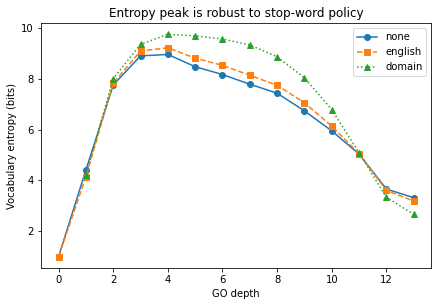

peak depth (none   ): 4
peak depth (english): 4
peak depth (domain ): 4


In [14]:
names = bp.name.tolist(); dep = bp.depth.to_numpy()
ent = {pol: depthwise_entropy(names, dep, stopwords=pol)
       for pol in ("none", "english", "domain")}
levels = sorted(ent["none"])
edf = pd.DataFrame(dict(depth=levels,
        none   =[ent["none"].get(L, np.nan)    for L in levels],
        english=[ent["english"].get(L, np.nan) for L in levels],
        domain =[ent["domain"].get(L, np.nan)  for L in levels]))
display(edf)

fig, ax = plt.subplots(figsize=(7, 4.5))
for col, sty in [("none", "o-"), ("english", "s--"), ("domain", "^:")]:
    ax.plot(edf.depth, edf[col], sty, label=col)
ax.set(xlabel="GO depth", ylabel="Vocabulary entropy (bits)",
       title="Entropy peak is robust to stop-word policy"); ax.legend(); plt.show()
for pol in ("none", "english", "domain"):
    print(f"peak depth ({pol:7s}):", max(ent[pol], key=ent[pol].get))

In [13]:
from go_lingdepth.entropy_models import fit_models, quadratic_peak, peak_leave_one_out

d = edf.depth.to_numpy(float); h = edf.english.to_numpy(float)
fits = fit_models(d, h)
print("empirical peak depth  :", int(d[int(np.argmax(h))]))
print("quadratic vertex      :", round(quadratic_peak(d, h), 2))
print("leave-one-out interval:", tuple(round(x, 2) for x in peak_leave_one_out(d, h)))
pd.DataFrame(fits).T[["r2", "aicc"]]

empirical peak depth  : 4
quadratic vertex      : 6.24
leave-one-out interval: (5.73, 6.37)


,r2,aicc
linear,0.017696,30.420922
log,0.066683,23.214971
quadratic,0.827701,9.360665


## 5. `nulls` — permutation test + Monte-Carlo entropy envelope

permutation nulls: {'observed': 0.36628949499461966, 'name_perm_p': 0.0, 'depth_perm_p': 0.0}


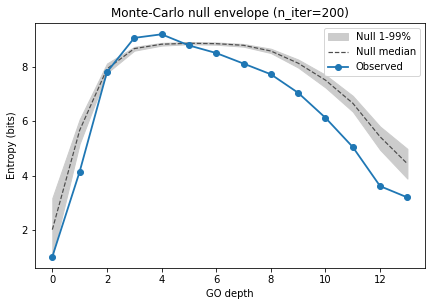

depths outside 1-99% null: [1, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13]


In [14]:
from go_lingdepth.nulls import permutation_null_corr, mc_entropy_envelope

L = bp.letters.to_numpy(float)
corr = permutation_null_corr(dep.astype(float), L, n_iter=N_ITER_NULL, seed=0)
print("permutation nulls:", corr)

env = mc_entropy_envelope(names, dep, n_iter=N_ITER_NULL, seed=42, stopwords="english")
fig, ax = plt.subplots(figsize=(7, 4.5))
ax.fill_between(env.depth, env.null_lo1, env.null_hi99, color="0.8", label="Null 1-99%")
ax.plot(env.depth, env.null_med, "--", color="0.3", lw=1.2, label="Null median")
ax.plot(env.depth, env.observed, "o-", color="tab:blue", lw=1.8, label="Observed")
ax.set(xlabel="GO depth", ylabel="Entropy (bits)",
       title=f"Monte-Carlo null envelope (n_iter={N_ITER_NULL})"); ax.legend(); plt.show()
print("depths outside 1-99% null:", env.loc[env.outside, "depth"].tolist())

## 6. `embeddings` + `clustering` (heavy)

Reuses the cached `results/emb_BP.npy` if present — so this runs even without
`sentence-transformers` installed. Set `RUN_HEAVY = False` (cell 0) to skip.

In [17]:
X = None
if RUN_HEAVY:
    from go_lingdepth.embeddings import embed_terms, pca_reduce
    cache = RESULTS / "emb_BP.npy"
    try:
        emb = embed_terms(names, cache_path=str(cache))   # loads cache, else encodes
        if emb.shape[0] != len(names):
            print(f"WARNING: cache rows ({emb.shape[0]}) != BP terms ({len(names)}); "
                  "re-encode by deleting", cache)
        X = pca_reduce(emb, n_components=50, seed=0)
        print("embeddings:", emb.shape, "-> PCA:", X.shape)
    except Exception as e:
        print("Embeddings skipped (no sentence-transformers and no cache):", repr(e))
else:
    print("RUN_HEAVY=False -> embeddings/clustering skipped")

embeddings: (24136, 384) -> PCA: (24136, 50)


In [18]:
if X is not None:
    from go_lingdepth.clustering import kmeans_labels, kselection, kw_depth_by_cluster
    val = kselection(X, KS_SWEEP, sample_size=5000, seed=0)
    kw_rows = []
    for k in KS_SWEEP:
        r = kw_depth_by_cluster(kmeans_labels(X, k, seed=0), dep)
        kw_rows.append(dict(k=k, kw_H=r["H"], kw_p=r["p"], eta2=round(r["eta2"], 3)))
    ksel = val.merge(pd.DataFrame(kw_rows), on="k")
    display(ksel)
    print("k* by silhouette         :", int(ksel.loc[ksel.silhouette.idxmax(), "k"]))
    print("k* by Davies-Bouldin(min):", int(ksel.loc[ksel.davies_bouldin.idxmin(), "k"]))

,k,inertia,silhouette,davies_bouldin,kw_H,kw_p,eta2
0,10,9087.498047,0.072542,2.951699,4186.873291,0.0,0.173
1,20,8239.321289,0.079196,2.770058,4730.253957,0.0,0.195
2,30,7658.182129,0.082525,2.648974,5489.646554,0.0,0.227
3,40,7292.582520,0.087484,2.615718,5563.423187,0.0,0.229
4,50,6988.125000,0.089990,2.503018,6012.415029,0.0,0.248


k* by silhouette         : 50
k* by Davies-Bouldin(min): 50


In [19]:
pip install -U numpy umap-learn numba pynndescent scikit-learn seaborn matplotlib

  Using cached numpy-1.24.4-cp38-cp38-win_amd64.whl.metadata (5.6 kB)
  Using cached umap_learn-0.5.8-py3-none-any.whl.metadata (23 kB)
INFO: pip is looking at multiple versions of umap-learn to determine which version is compatible with other requirements. This could take a while.


  You can safely remove it manually.
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
tensorflow-intel 2.13.0 requires numpy<=1.24.3,>=1.22, but you have numpy 1.24.4 which is incompatible.
tensorflow-intel 2.13.0 requires typing-extensions<4.6.0,>=3.6.6, but you have typing-extensions 4.12.2 which is incompatible.



Using cached numpy-1.24.4-cp38-cp38-win_amd64.whl (14.9 MB)
  Attempting uninstall: numpy
    Found existing installation: numpy 1.23.5
    Uninstalling numpy-1.23.5:
      Successfully uninstalled numpy-1.23.5


In [20]:
pip install numpy==1.23.5

Note: you may need to restart the kernel to use updated packages.


In [21]:
import sys, numpy as np
import importlib.metadata as md

print("Python executable:", sys.executable)
print("NumPy version:", np.__version__)
print("NumPy file:", np.__file__)

for pkg in ["umap-learn", "umap", "numba", "pynndescent", "scikit-learn"]:
    try:
        print(pkg, "=", md.version(pkg))
    except Exception as e:
        print(pkg, "not found")

Python executable: C:\anaconda3\python.exe
NumPy version: 1.24.3
NumPy file: C:\anaconda3\lib\site-packages\numpy\__init__.py
umap-learn = 0.5.7
umap = 0.1.1
numba = 0.58.1
pynndescent = 0.6.0
scikit-learn = 1.3.2


In [22]:
import traceback
import umap

labels = kmeans_labels(X, 20, seed=0)
xy = umap.UMAP(n_neighbors=15, min_dist=0.1, random_state=0).fit_transform(X)

In [23]:
import sys

!{sys.executable} -m pip uninstall -y umap
!{sys.executable} -m pip uninstall -y umap-learn
!{sys.executable} -m pip install --no-cache-dir umap-learn==0.5.7

Found existing installation: umap 0.1.1
Uninstalling umap-0.1.1:
  Successfully uninstalled umap-0.1.1
Found existing installation: umap-learn 0.5.7
Uninstalling umap-learn-0.5.7:
  Successfully uninstalled umap-learn-0.5.7


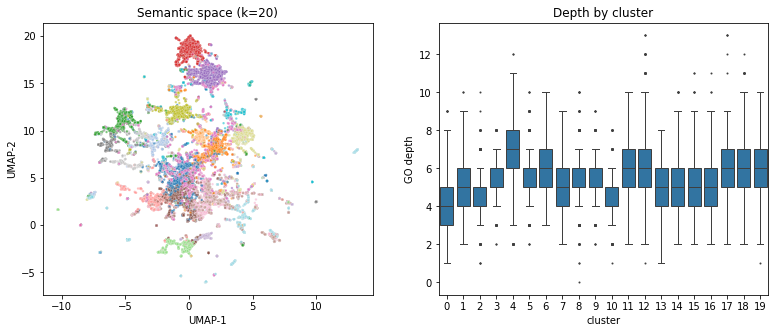

In [20]:
if X is not None:
    try:
        import umap, seaborn as sns
        labels = kmeans_labels(X, 20, seed=0)
        xy = umap.UMAP(n_neighbors=15, min_dist=0.1, random_state=0).fit_transform(X)
        fig, ax = plt.subplots(1, 2, figsize=(13, 5))
        sns.scatterplot(x=xy[:, 0], y=xy[:, 1], hue=labels, palette="tab20",
                        s=6, alpha=0.6, legend=False, ax=ax[0])
        ax[0].set(xlabel="UMAP-1", ylabel="UMAP-2", title="Semantic space (k=20)")
        sns.boxplot(x=labels, y=dep, fliersize=1, ax=ax[1])
        ax[1].set(xlabel="cluster", ylabel="GO depth", title="Depth by cluster")
        plt.show()
    except Exception as e:
        print("UMAP visualization skipped:", repr(e))

## 7. `synthetic` — signal/noise discrimination + vocabulary evolution

,Name,Level,Length
0,signal pathway ribosomal metabolism,4,35
1,pathway ribosomal signal cycle,5,30
2,mitochondrial binding process cell glycolytic,7,45
3,transport binding metabolism transport signal ...,9,53
4,regulation process,0,18
5,signal process,1,14
6,pathway binding process signal pathway binding,8,46
7,protein metabolism protein cell transport cell,9,46


,mode,mean_corr,sd_corr
0,signal,0.900062,0.003787
1,noise,-0.003529,0.012979
2,mixed,0.458782,0.012834


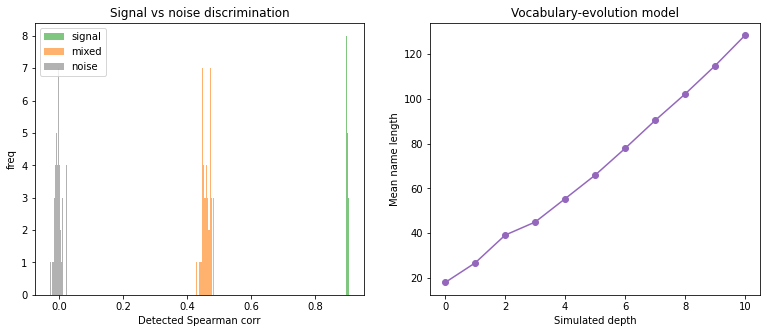

In [21]:
from go_lingdepth.synthetic import (
    generate_dataset, signal_noise_separation, simulate_vocab_evolution)

display(generate_dataset("signal", n_terms=8, seed=1))
sep = signal_noise_separation(reps=50, seed=0)
display(sep)

ev = simulate_vocab_evolution(max_depth=12, branching=4, max_nodes=25000, seed=0)
fig, ax = plt.subplots(1, 2, figsize=(13, 5))
for mode, col in [("signal", "tab:green"), ("mixed", "tab:orange"), ("noise", "0.5")]:
    corrs = [generate_dataset(mode, seed=r).corr(numeric_only=True).loc["Level", "Length"]
             for r in range(50)]
    ax[0].hist(corrs, bins=20, alpha=0.6, color=col, label=mode)
ax[0].set(xlabel="Detected Spearman corr", ylabel="freq",
          title="Signal vs noise discrimination"); ax[0].legend()
g = ev.groupby("depth")["length"].mean()
ax[1].plot(g.index, g.values, "o-", color="tab:purple")
ax[1].set(xlabel="Simulated depth", ylabel="Mean name length",
          title="Vocabulary-evolution model"); plt.show()

## 8. Headline figure — term-name length vs GO depth

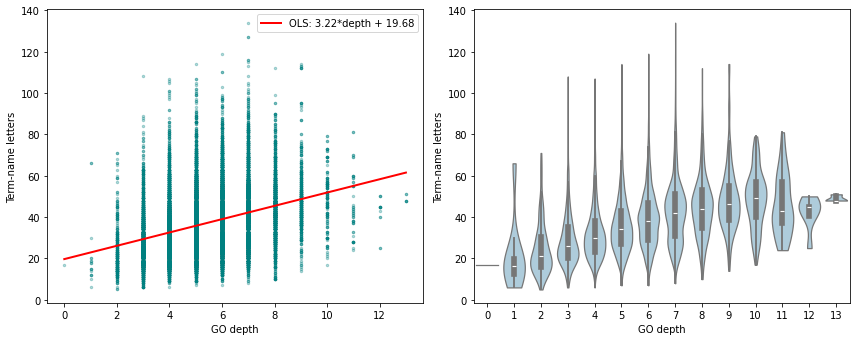

In [22]:
s, b = np.polyfit(bp.depth, bp.letters, 1)
xs = np.arange(bp.depth.min(), bp.depth.max() + 1)
fig, ax = plt.subplots(1, 2, figsize=(12, 5))
ax[0].scatter(bp.depth, bp.letters, s=6, alpha=0.3, color="teal")
ax[0].plot(xs, s * xs + b, "r-", lw=2, label=f"OLS: {s:.2f}*depth + {b:.2f}")
ax[0].set(xlabel="GO depth", ylabel="Term-name letters"); ax[0].legend()
try:
    import seaborn as sns
    sns.violinplot(data=bp, x="depth", y="letters", cut=0,
                   density_norm="width", color="#a6cee3", ax=ax[1])
except Exception:
    bp.boxplot(column="letters", by="depth", ax=ax[1]); ax[1].set_title("")
ax[1].set(xlabel="GO depth", ylabel="Term-name letters")
plt.suptitle(""); plt.tight_layout(); plt.show()

## Done

This notebook covered every `go_lingdepth` module: `obo_parser`, `depth`,
`linguistics`, `entropy_models`, `nulls`, `embeddings`, `clustering`,
`synthetic` (plus the package's `plotting` helpers are exercised inline here).

**To reach full paper fidelity**, in cell 0 set `N_ITER_NULL = 1000` and
`KS_SWEEP = list(range(10, 51, 5))`, then *Run All*.

For the canonical, file-writing pipeline (CSVs + PDF/PNG figures into
`results/` and `figures/`), use the scripts instead:
```bash
PYTHONHASHSEED=0 python scripts/run_all.py
```